# RBI Currency in Circulation: Data Story

In [1]:
print("Hello")

Hello


## Introduction

This notebook analyses Reserve Bank of India data on currency in circulation to identify patterns and a potential data-driven story.

## 1. Data Collection

In [2]:
import pandas as pd

In [3]:
file = "RBI_Currency_Historical_Data.xlsx"

In [4]:
excel_data = pd.ExcelFile(file)

In [5]:
excel_data.sheet_names

['Weekly_Extract', 'Annual_Denomination', 'Sources']

In [6]:
weekly = pd.read_excel(file, sheet_name="Weekly_Extract")

In [7]:
weekly.head()

,Date,Category,Denomination,Volume_lakh_pieces,Value_crore
0,2024-09-27,Banknote,2 and 5,110445.0,4243.0
1,2024-09-27,Banknote,10,247647.0,24765.0
2,2024-09-27,Banknote,20,132871.0,26574.0
3,2024-09-27,Banknote,50,89837.0,44918.0
4,2024-09-27,Banknote,100,202284.0,202284.0


In [8]:
weekly.shape

(80, 5)

In [9]:
weekly.columns

Index(['Date', 'Category', 'Denomination', 'Volume_lakh_pieces',
       'Value_crore'],
      dtype='str')

In [10]:
weekly["Date"].unique()

<DatetimeArray>
['2024-09-27 00:00:00', '2024-10-11 00:00:00', '2024-11-01 00:00:00',
 '2024-11-08 00:00:00', '2026-08-14 00:00:00']
Length: 5, dtype: datetime64[us]

In [11]:
annual = pd.read_excel(file, sheet_name="Annual_Denomination")

In [12]:
annual.head()

,Date,Denomination,Volume_million_pieces,Value_billion_rupees
0,2016-03-31,2 and 5,11626,45
1,2016-03-31,10,32015,320
2,2016-03-31,20,4924,98
3,2016-03-31,50,3890,194
4,2016-03-31,100,15778,1578


In [13]:
annual.shape

(36, 4)

In [14]:
annual.shape

(36, 4)

In [15]:
annual.columns

Index(['Date', 'Denomination', 'Volume_million_pieces',
       'Value_billion_rupees'],
      dtype='str')

In [16]:
annual

,Date,Denomination,Volume_million_pieces,Value_billion_rupees
0,2016-03-31,2 and 5,11626,45
1,2016-03-31,10,32015,320
2,2016-03-31,20,4924,98
3,2016-03-31,50,3890,194
4,2016-03-31,100,15778,1578
5,2016-03-31,200,0,0
6,2016-03-31,500,15707,7854
7,2016-03-31,1000,6326,6326
8,2016-03-31,2000,0,0
9,2017-03-31,2 and 5,11557,45


In [17]:
annual["Date"].unique()

<DatetimeArray>
['2016-03-31 00:00:00', '2017-03-31 00:00:00', '2018-03-31 00:00:00',
 '2019-03-31 00:00:00']
Length: 4, dtype: datetime64[us]

In [18]:
annual["Denomination"].unique()

<StringArray>
['2 and 5', '10', '20', '50', '100', '200', '500', '1000', '2000']
Length: 9, dtype: str

In [19]:
annual.groupby("Date")["Volume_million_pieces"].sum()

Date
2016-03-31     90266
2017-03-31    100293
2018-03-31    102395
2019-03-31    108759
Name: Volume_million_pieces, dtype: int64

In [20]:
annual.pivot(
    index="Denomination",
    columns="Date",
    values="Volume_million_pieces"
)

Date,2016-03-31,2017-03-31,2018-03-31,2019-03-31
Denomination,,,,
10,32015,36929,30645,31260
100,15778,25280,22215,20074
1000,6326,89,66,0
2 and 5,11626,11557,11425,11302
20,4924,10158,10016,8713
200,0,0,1853,4000
2000,0,3285,3363,3291
50,3890,7113,7343,8601
500,15707,5882,15469,21518


In [21]:
pivot = annual.pivot(
    index="Denomination",
    columns="Date",
    values="Volume_million_pieces"
)

percentage_change = ((pivot["2019-03-31"] - pivot["2016-03-31"]) / pivot["2016-03-31"]) * 100

percentage_change

Denomination
10          -2.358270
100         27.227786
1000      -100.000000
2 and 5     -2.786857
20          76.949634
200               inf
2000              inf
50         121.105398
500         36.996244
dtype: float64

In [22]:
annual.pivot(
    index="Denomination",
    columns="Date",
    values="Value_billion_rupees"
)

Date,2016-03-31,2017-03-31,2018-03-31,2019-03-31
Denomination,,,,
10,320,369,307,313
100,1578,2528,2222,2007
1000,6326,89,66,0
2 and 5,45,45,44,44
20,98,203,200,174
200,0,0,371,800
2000,0,6571,6726,6582
50,194,356,367,430
500,7854,2941,7734,10759


In [23]:
value_pivot = annual.pivot(
    index="Denomination",
    columns="Date",
    values="Value_billion_rupees"
)

value_change = (
    (value_pivot["2019-03-31"] - value_pivot["2016-03-31"])
    / value_pivot["2016-03-31"]
) * 100

value_change

Denomination
10          -2.187500
100         27.186312
1000      -100.000000
2 and 5     -2.222222
20          77.551020
200               inf
2000              inf
50         121.649485
500         36.987522
dtype: float64

In [24]:
annual.groupby("Date")["Value_billion_rupees"].sum()

Date
2016-03-31    16415
2017-03-31    13102
2018-03-31    18037
2019-03-31    21109
Name: Value_billion_rupees, dtype: int64

In [26]:
import matplotlib.pyplot as plt

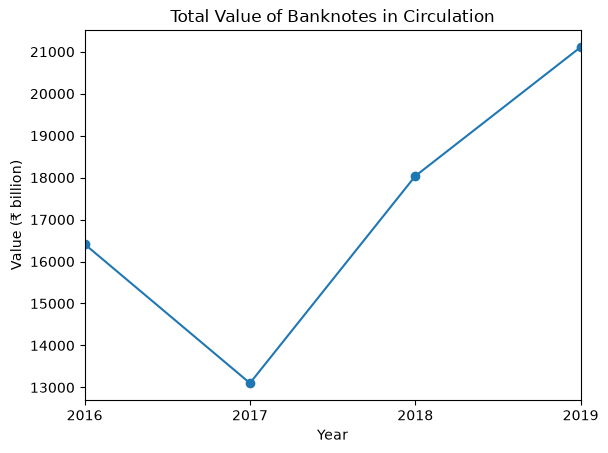

In [27]:
total_value = annual.groupby("Date")["Value_billion_rupees"].sum()

total_value.plot(
    kind="line",
    marker="o",
    title="Total Value of Banknotes in Circulation",
    xlabel="Year",
    ylabel="Value (₹ billion)"
)

plt.show()

## 2. Denomination-wise Changes

In [29]:
annual.groupby("Date")["Volume_million_pieces"].sum()

Date
2016-03-31     90266
2017-03-31    100293
2018-03-31    102395
2019-03-31    108759
Name: Volume_million_pieces, dtype: int64

The total number of banknotes in circulation increased from 90.3 billion pieces in 2016 to 108.8 billion pieces in 2019. This indicates an overall increase in the volume of currency in circulation during the period.

In [30]:
annual.pivot(
    index="Denomination",
    columns="Date",
    values="Volume_million_pieces"
)

Date,2016-03-31,2017-03-31,2018-03-31,2019-03-31
Denomination,,,,
10,32015,36929,30645,31260
100,15778,25280,22215,20074
1000,6326,89,66,0
2 and 5,11626,11557,11425,11302
20,4924,10158,10016,8713
200,0,0,1853,4000
2000,0,3285,3363,3291
50,3890,7113,7343,8601
500,15707,5882,15469,21518


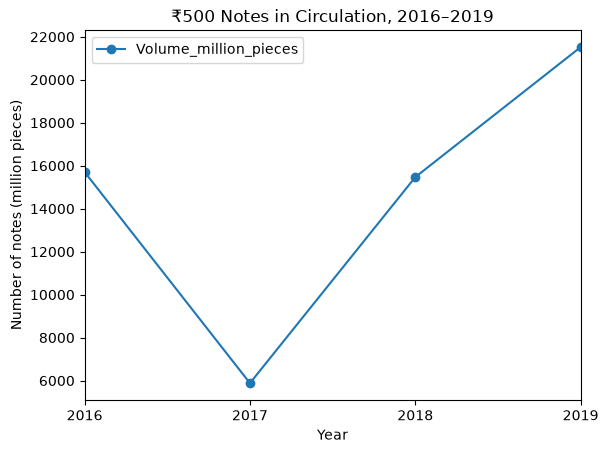

In [31]:
rs500 = annual[annual["Denomination"] == "500"]

rs500.plot(
    x="Date",
    y="Volume_million_pieces",
    kind="line",
    marker="o",
    title="₹500 Notes in Circulation, 2016–2019",
    xlabel="Year",
    ylabel="Number of notes (million pieces)"
)

plt.show()

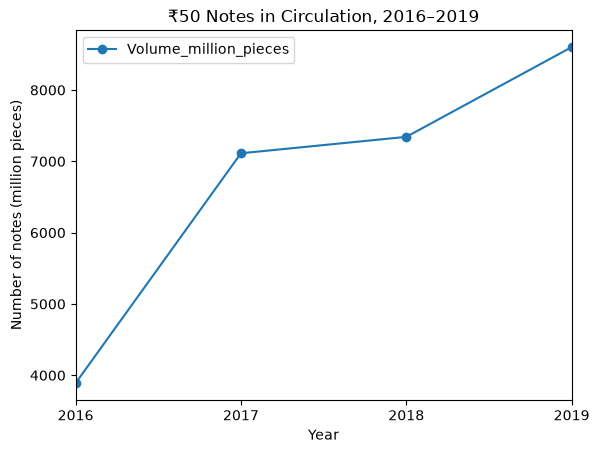

In [32]:
rs50 = annual[annual["Denomination"] == "50"]

rs50.plot(
    x="Date",
    y="Volume_million_pieces",
    kind="line",
    marker="o",
    title="₹50 Notes in Circulation, 2016–2019",
    xlabel="Year",
    ylabel="Number of notes (million pieces)"
)

plt.show()

The denomination-wise data shows a significant shift in the composition of banknotes between 2016 and 2019. While the number of ₹500 notes fell sharply in 2017 before recovering, ₹50 notes more than doubled over the period, rising from 3.89 billion pieces to 8.60 billion pieces.

In [33]:
high_value = annual[annual["Denomination"].isin(["1000", "2000"])]

high_value

,Date,Denomination,Volume_million_pieces,Value_billion_rupees
7,2016-03-31,1000,6326,6326
8,2016-03-31,2000,0,0
16,2017-03-31,1000,89,89
17,2017-03-31,2000,3285,6571
25,2018-03-31,1000,66,66
26,2018-03-31,2000,3363,6726
34,2019-03-31,1000,0,0
35,2019-03-31,2000,3291,6582


## Story Pitch

### ₹50 Notes More Than Double as India's Cash Mix Shifts

The number of ₹50 notes in circulation more than doubled between March 2016 and March 2019, rising 121% from 3.89 billion to 8.60 billion pieces, according to Reserve Bank of India data analysed in this notebook. ₹20 notes also rose 77% over the same period, while ₹500 notes increased 37%.

The shift came alongside a sharp change in India's higher-value currency. The number of ₹1,000 notes fell 100% to zero, while ₹2,000 notes appeared in circulation from 2017. Overall, the number of banknotes in circulation rose from 90.3 billion pieces in 2016 to 108.8 billion in 2019.

The story would examine what drove the rapid increase in lower-denomination notes and how the denomination mix of India's cash economy changed following demonetisation. Interviews with economists, currency experts and bankers could help establish whether the changes reflected altered cash-use patterns, replacement of withdrawn denominations, or changes in demand for smaller-value transactions.